In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/who-are-our-important-customers/submission.csv
/kaggle/input/who-are-our-important-customers/train_df.csv
/kaggle/input/who-are-our-important-customers/test_df.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
test = pd.read_csv('/kaggle/input/who-are-our-important-customers/test_df.csv')
test.head()

,id,purchase_amount,asset_amount,average_ratio,personal_id_1,personal_id_2,age,area,job_type,phone,personal_card_1,personal_card_2,personal_card_3,personal_card_4,car,purchase_score,campaign_use,card_expired,average_favorite_score,card_history_period,score_1,score_2,score_3,score_4,total_amount_1,total_amount_2,total_amount_3
0,17500,58752.0,94352,84.560755,244,45,35,1323.0,NaN,1,1,0.0,1,0.0,0,709,3.0,1.0,1.607419,4.221710,0,8,0,1.0,43535,143553,388
1,17501,41109.0,69151,83.127703,830,67,34,863.0,Salaried,1,1,0.0,0,0.0,0,814,0.0,0.0,0.001650,0.525210,0,11,2,NaN,73287,8895,1382
2,17502,61863.0,59134,61.132690,2549,45,28,1231.0,Salaried,1,0,0.0,1,NaN,0,3,0.0,NaN,0.006573,0.020912,0,1,0,0.0,4457,15008,2205
3,17503,38018.0,117158,88.415083,1602,120,36,7084.0,Self employed,1,0,0.0,1,NaN,1,16,0.0,0.0,1.247141,1.898690,1,22,0,NaN,634723,41942,95
4,17504,41180.0,77888,85.455052,2058,45,38,996.0,Self employed,1,1,NaN,0,0.0,0,4,0.0,0.0,0.016552,0.034810,0,2,0,0.0,99731,13895,1871


In [4]:
train = pd.read_csv('/kaggle/input/who-are-our-important-customers/train_df.csv')
train.head()

,id,purchase_amount,asset_amount,average_ratio,personal_id_1,personal_id_2,age,area,job_type,phone,personal_card_1,personal_card_2,personal_card_3,personal_card_4,car,purchase_score,campaign_use,card_expired,average_favorite_score,card_history_period,score_1,score_2,score_3,score_4,total_amount_1,total_amount_2,total_amount_3,important_customer
0,0,62978.0,64016,87.170255,1256,86,44,NaN,Salaried,1,1,NaN,0,1.0,0,0,0.0,0.0,0.010922,0.048340,0,7,0,0.0,58620,10590,1392,0
1,1,66790.0,64497,83.609102,666,86,30,5318.0,Salaried,1,0,0.0,1,0.0,0,705,0.0,0.0,1.687598,1.701259,0,0,6,0.0,70809,9575,889,0
2,2,57788.0,111404,58.986180,1621,120,36,5954.0,Self employed,1,1,0.0,0,NaN,0,309,2.0,1.0,0.001265,3.483625,0,9,6,0.0,55294,38319,779,0
3,3,59729.0,63983,72.702121,1731,51,27,7263.0,NaN,1,0,0.0,0,0.0,0,740,0.0,0.0,0.015441,3.338835,0,1,2,0.0,1972,9314,2081,0
4,4,50533.0,98623,82.218856,801,86,40,6270.0,NaN,1,1,0.0,0,0.0,0,3,0.0,0.0,0.001283,0.067355,0,2,0,0.0,4942,10484,1772,0


In [5]:
combined = pd.concat([test,train])
combined.head()

,id,purchase_amount,asset_amount,average_ratio,personal_id_1,personal_id_2,age,area,job_type,phone,personal_card_1,personal_card_2,personal_card_3,personal_card_4,car,purchase_score,campaign_use,card_expired,average_favorite_score,card_history_period,score_1,score_2,score_3,score_4,total_amount_1,total_amount_2,total_amount_3,important_customer
0,17500,58752.0,94352,84.560755,244,45,35,1323.0,NaN,1,1,0.0,1,0.0,0,709,3.0,1.0,1.607419,4.221710,0,8,0,1.0,43535,143553,388,NaN
1,17501,41109.0,69151,83.127703,830,67,34,863.0,Salaried,1,1,0.0,0,0.0,0,814,0.0,0.0,0.001650,0.525210,0,11,2,NaN,73287,8895,1382,NaN
2,17502,61863.0,59134,61.132690,2549,45,28,1231.0,Salaried,1,0,0.0,1,NaN,0,3,0.0,NaN,0.006573,0.020912,0,1,0,0.0,4457,15008,2205,NaN
3,17503,38018.0,117158,88.415083,1602,120,36,7084.0,Self employed,1,0,0.0,1,NaN,1,16,0.0,0.0,1.247141,1.898690,1,22,0,NaN,634723,41942,95,NaN
4,17504,41180.0,77888,85.455052,2058,45,38,996.0,Self employed,1,1,NaN,0,0.0,0,4,0.0,0.0,0.016552,0.034810,0,2,0,0.0,99731,13895,1871,NaN


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25000 entries, 0 to 17499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      25000 non-null  int64  
 1   purchase_amount         22461 non-null  float64
 2   asset_amount            25000 non-null  int64  
 3   average_ratio           25000 non-null  float64
 4   personal_id_1           25000 non-null  int64  
 5   personal_id_2           25000 non-null  int64  
 6   age                     25000 non-null  int64  
 7   area                    22525 non-null  float64
 8   job_type                22524 non-null  object 
 9   phone                   25000 non-null  int64  
 10  personal_card_1         25000 non-null  int64  
 11  personal_card_2         22566 non-null  float64
 12  personal_card_3         25000 non-null  int64  
 13  personal_card_4         22531 non-null  float64
 14  car                     25000 non-null

In [7]:
combined.dtypes

id                          int64
purchase_amount           float64
asset_amount                int64
average_ratio             float64
personal_id_1               int64
personal_id_2               int64
age                         int64
area                      float64
job_type                   object
phone                       int64
personal_card_1             int64
personal_card_2           float64
personal_card_3             int64
personal_card_4           float64
car                         int64
purchase_score              int64
campaign_use              float64
card_expired              float64
average_favorite_score    float64
card_history_period       float64
score_1                     int64
score_2                     int64
score_3                     int64
score_4                   float64
total_amount_1              int64
total_amount_2              int64
total_amount_3              int64
important_customer        float64
dtype: object

In [8]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,25000.0,12499.500000,7217.022701,0.000000,6249.750000,12499.500000,18749.250000,2.499900e+04
purchase_amount,22461.0,46999.354570,15001.131136,7964.000000,38582.000000,46289.000000,54178.000000,1.344210e+05
asset_amount,25000.0,75613.512440,19547.327432,41429.000000,65935.000000,68560.000000,75614.000000,1.888440e+05
average_ratio,25000.0,73.412008,11.312791,24.185127,69.511994,75.707362,82.183697,9.024397e+01
personal_id_1,25000.0,1434.432400,934.511392,1.000000,647.000000,1322.000000,2153.000000,3.791000e+03
personal_id_2,25000.0,69.546760,26.740632,45.000000,48.000000,51.000000,86.000000,1.530000e+02
age,25000.0,35.018200,7.821923,21.000000,27.000000,36.000000,42.000000,5.000000e+01
area,22525.0,3432.488879,2274.586756,2.000000,1532.000000,2992.000000,5735.000000,7.341000e+03
phone,25000.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00
personal_card_1,25000.0,0.675960,0.468024,0.000000,0.000000,1.000000,1.000000,1.000000e+00


In [9]:
combined.isnull().sum()/len(combined)*100

id                         0.000
purchase_amount           10.156
asset_amount               0.000
average_ratio              0.000
personal_id_1              0.000
personal_id_2              0.000
age                        0.000
area                       9.900
job_type                   9.904
phone                      0.000
personal_card_1            0.000
personal_card_2            9.736
personal_card_3            0.000
personal_card_4            9.876
car                        0.000
purchase_score             0.000
campaign_use              10.004
card_expired               9.756
average_favorite_score     0.000
card_history_period        0.000
score_1                    0.000
score_2                    0.000
score_3                    0.000
score_4                    9.904
total_amount_1             0.000
total_amount_2             0.000
total_amount_3             0.000
important_customer        30.000
dtype: float64

In [10]:
combined.shape

(25000, 28)

In [11]:
combined.skew()

/tmp/ipykernel_20/3158812268.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.skew()


id                        0.000000
purchase_amount           0.666318
asset_amount              2.501456
average_ratio            -1.289468
personal_id_1             0.357455
personal_id_2             1.041865
age                      -0.029127
area                      0.269583
phone                     0.000000
personal_card_1          -0.751987
personal_card_2           2.143839
personal_card_3           1.794253
personal_card_4           4.120245
car                       3.017507
purchase_score           -0.334524
campaign_use              3.169148
card_expired              4.465357
average_favorite_score    2.667094
card_history_period       2.205898
score_1                   2.912771
score_2                   2.323382
score_3                   2.744703
score_4                   2.959236
total_amount_1            5.289326
total_amount_2            4.602979
total_amount_3            9.512320
important_customer        1.723117
dtype: float64

In [12]:
combined.kurt()

/tmp/ipykernel_20/292944781.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.kurt()


id                         -1.200000
purchase_amount             1.409180
asset_amount                7.112727
average_ratio               1.593863
personal_id_1              -0.913953
personal_id_2               0.598861
age                        -1.349028
area                       -1.287529
phone                       0.000000
personal_card_1            -1.434631
personal_card_2             2.596275
personal_card_3             1.219442
personal_card_4            14.977749
car                         7.105914
purchase_score             -1.735643
campaign_use               12.333625
card_expired               20.787021
average_favorite_score      8.640709
card_history_period         5.358202
score_1                     9.021061
score_2                     6.309427
score_3                    11.985453
score_4                     8.261243
total_amount_1             31.944497
total_amount_2             24.764379
total_amount_3            102.061006
important_customer          0.969244
d

<Axes: >

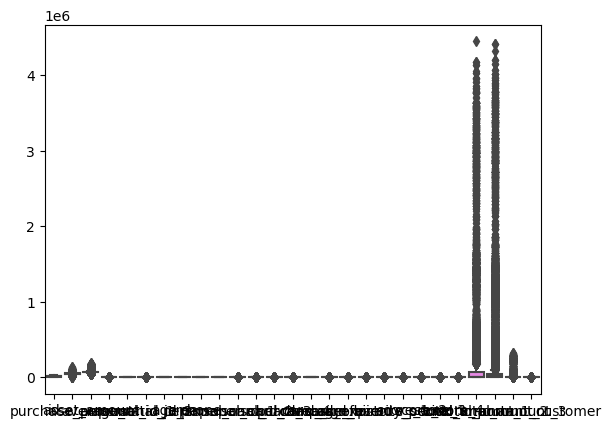

In [13]:
sns.boxplot(combined)

/tmp/ipykernel_20/3062371967.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(combined)


<Axes: ylabel='Density'>

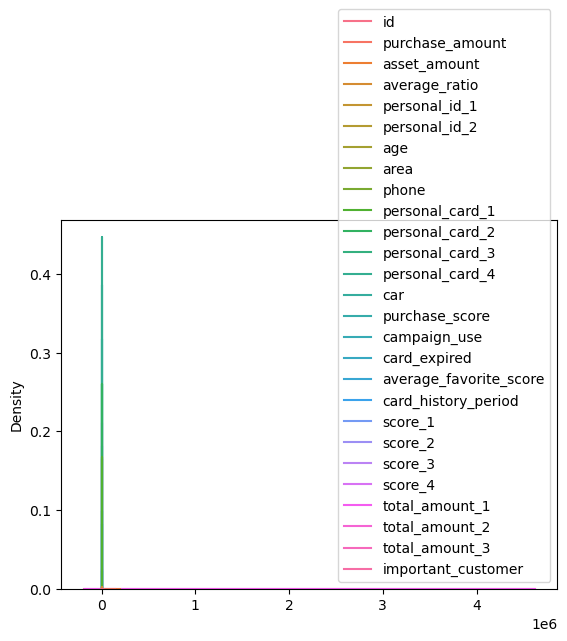

In [14]:
sns.kdeplot(combined)

<Axes: >

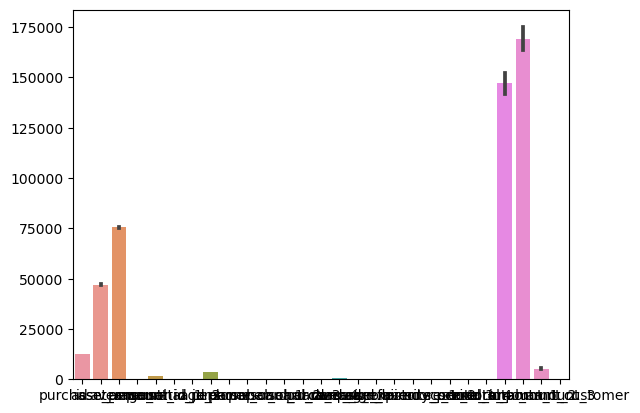

In [15]:
sns.barplot(combined)

<Axes: >

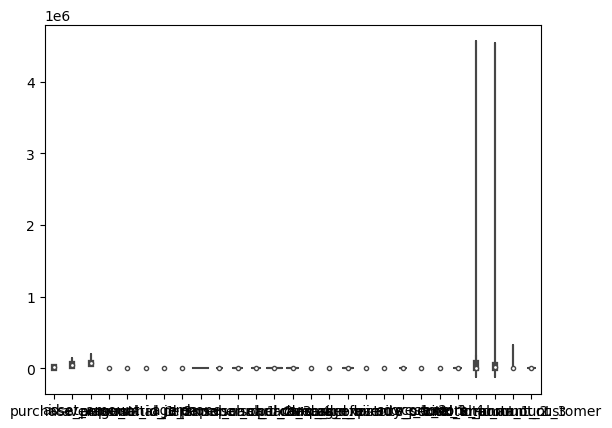

In [16]:
sns.violinplot(combined)

<Axes: >

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


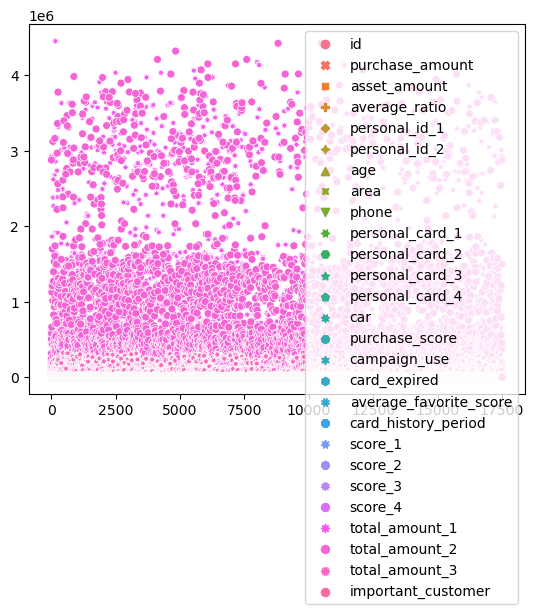

In [17]:
sns.scatterplot(combined)

In [18]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

id                        12499.500000
purchase_amount           15596.000000
asset_amount               9679.000000
average_ratio                12.671703
personal_id_1              1506.000000
personal_id_2                38.000000
age                          15.000000
area                       4203.000000
phone                         0.000000
personal_card_1               1.000000
personal_card_2               0.000000
personal_card_3               0.000000
personal_card_4               0.000000
car                           0.000000
purchase_score              717.000000
campaign_use                  1.000000
card_expired                  0.000000
average_favorite_score        0.504150
card_history_period           2.247198
score_1                       0.000000
score_2                       4.000000
score_3                       2.000000
score_4                       0.000000
total_amount_1            69825.250000
total_amount_2            34708.250000
total_amount_3           

/tmp/ipykernel_20/2240195514.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = combined.quantile(0.25)
/tmp/ipykernel_20/2240195514.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = combined.quantile(0.5)
/tmp/ipykernel_20/2240195514.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = combined.quantile(0.75)


In [19]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [20]:
combined_new = combined[~((combined>UL)|(combined<LL)).any(axis=1)]

/tmp/ipykernel_20/1551434999.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  combined_new = combined[~((combined>UL)|(combined<LL)).any(axis=1)]


In [21]:
combined_new.shape

(7680, 28)

/tmp/ipykernel_20/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<Axes: >

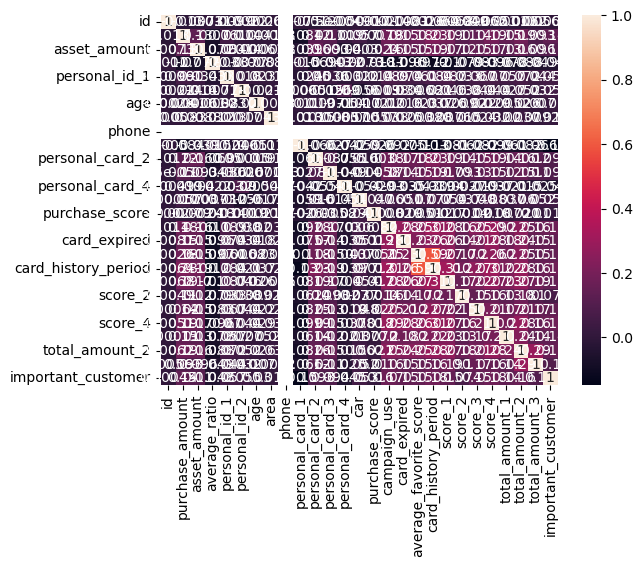

In [22]:
sns.heatmap(combined.corr(),annot=True)

In [23]:
cat_cols = combined.select_dtypes(include='object')

In [24]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)
    

job_type
Self employed    12412
Salaried         10112
Name: job_type, dtype: int64
__________________________________________________


In [25]:
num_cols = combined.select_dtypes(include='number')

In [26]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

id
17500    1
9150     1
9172     1
9171     1
9170     1
        ..
831      1
830      1
829      1
828      1
17499    1
Name: id, Length: 25000, dtype: int64
__________________________________________________
purchase_amount
46514.0    10
45983.0     8
49150.0     7
49285.0     7
41293.0     7
           ..
69011.0     1
62649.0     1
46352.0     1
68282.0     1
50681.0     1
Name: purchase_amount, Length: 13463, dtype: int64
__________________________________________________
asset_amount
67294     12
66058     11
69889     11
66303     11
69095     10
          ..
65799      1
108756     1
67198      1
99593      1
145082     1
Name: asset_amount, Length: 12145, dtype: int64
__________________________________________________
average_ratio
84.560755    2
51.849898    2
77.305498    2
68.645065    2
78.693862    2
            ..
83.292450    1
47.734283    1
72.983697    1
76.246616    1
79.692198    1
Name: average_ratio, Length: 16881, dtype: int64
________________________________

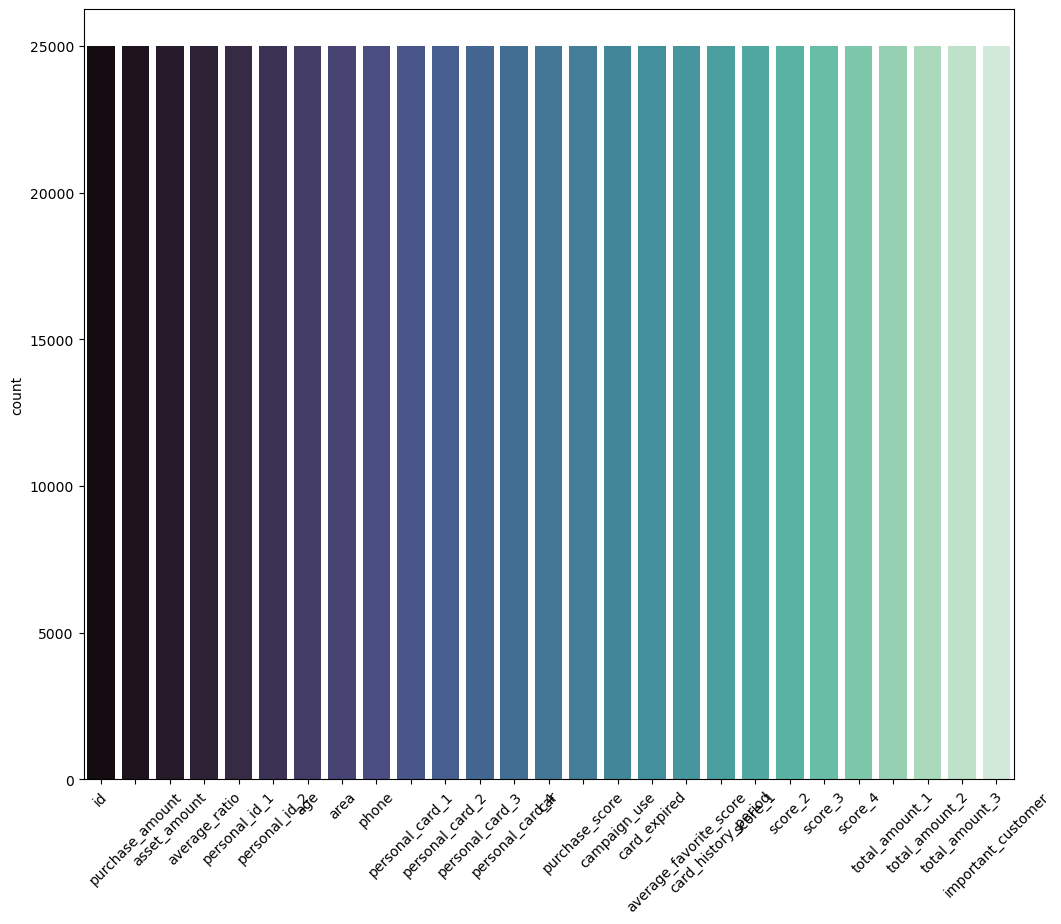

In [27]:
plt.figure(figsize=(12,10))
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=45);

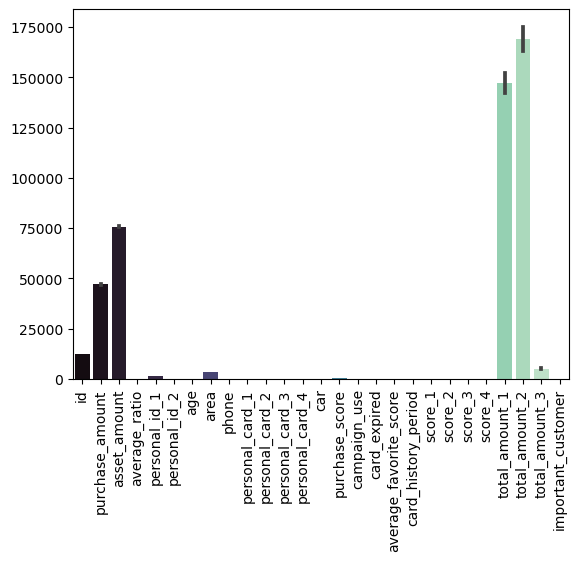

In [28]:
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=90);

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26]),
 [Text(0, 0, 'id'),
  Text(1, 0, 'purchase_amount'),
  Text(2, 0, 'asset_amount'),
  Text(3, 0, 'average_ratio'),
  Text(4, 0, 'personal_id_1'),
  Text(5, 0, 'personal_id_2'),
  Text(6, 0, 'age'),
  Text(7, 0, 'area'),
  Text(8, 0, 'phone'),
  Text(9, 0, 'personal_card_1'),
  Text(10, 0, 'personal_card_2'),
  Text(11, 0, 'personal_card_3'),
  Text(12, 0, 'personal_card_4'),
  Text(13, 0, 'car'),
  Text(14, 0, 'purchase_score'),
  Text(15, 0, 'campaign_use'),
  Text(16, 0, 'card_expired'),
  Text(17, 0, 'average_favorite_score'),
  Text(18, 0, 'card_history_period'),
  Text(19, 0, 'score_1'),
  Text(20, 0, 'score_2'),
  Text(21, 0, 'score_3'),
  Text(22, 0, 'score_4'),
  Text(23, 0, 'total_amount_1'),
  Text(24, 0, 'total_amount_2'),
  Text(25, 0, 'total_amount_3'),
  Text(26, 0, 'important_customer')])

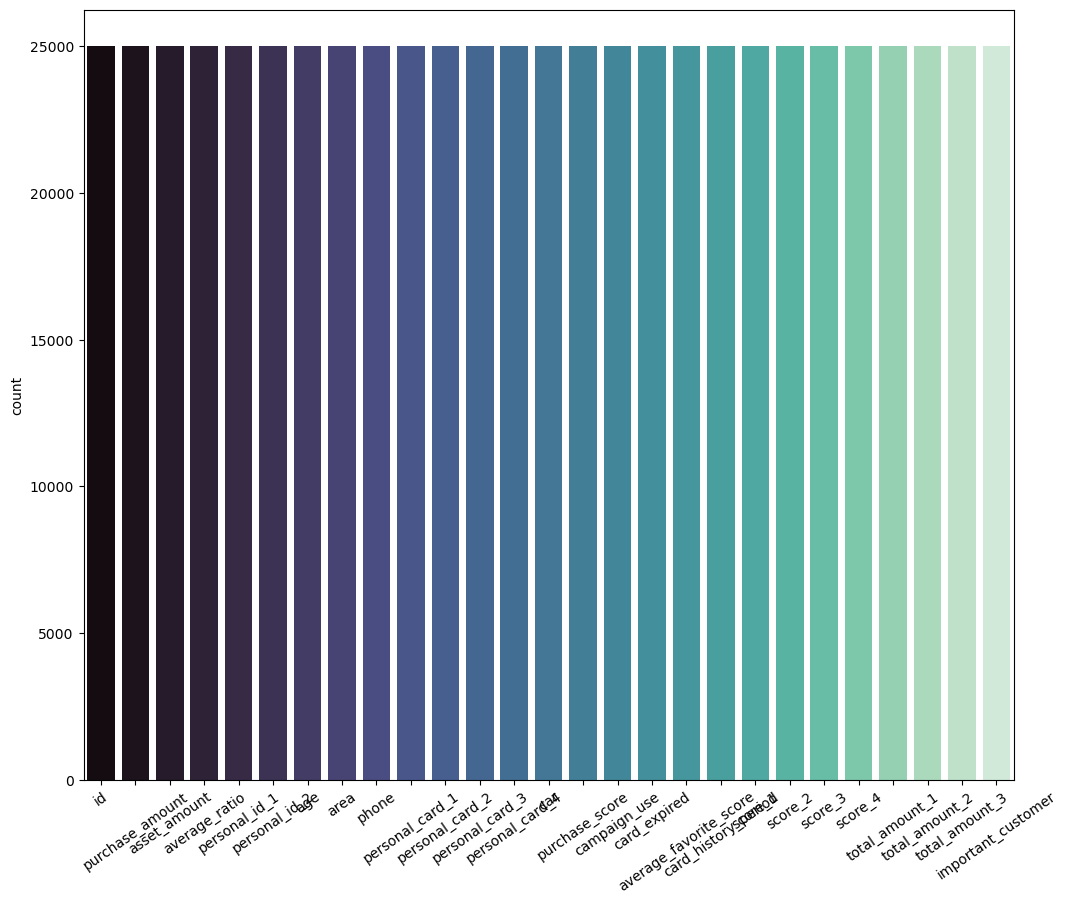

In [29]:
plt.figure(figsize=(12,10))
sns.countplot(data=combined,palette='mako')
plt.xticks(rotation=35)

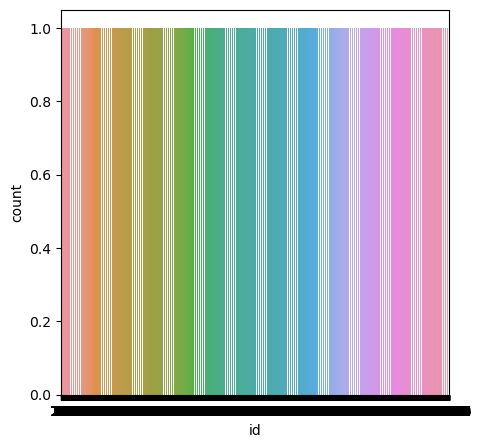

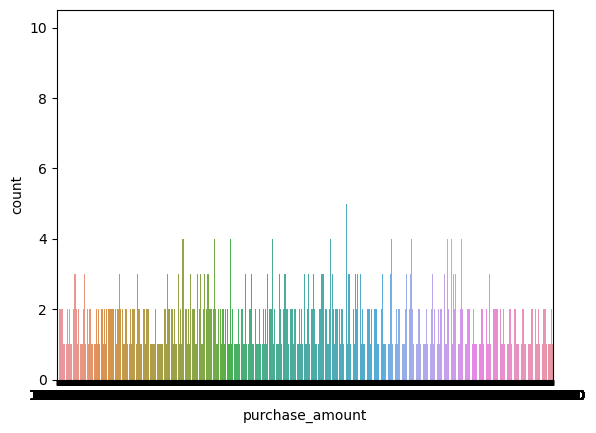

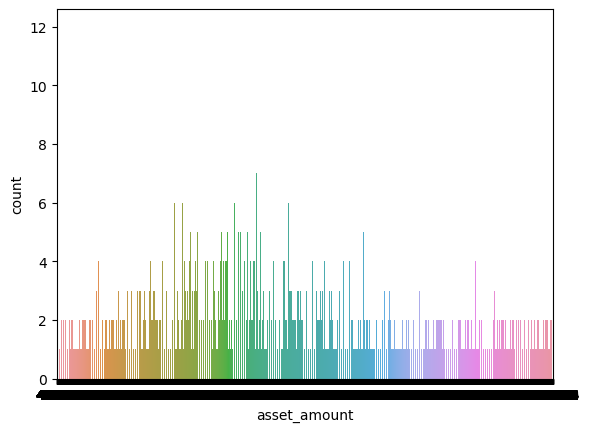

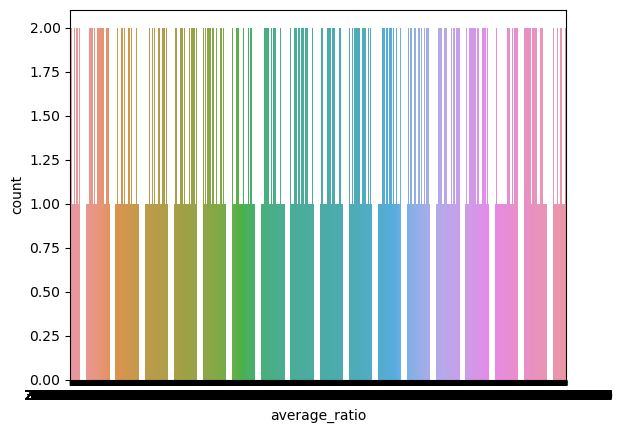

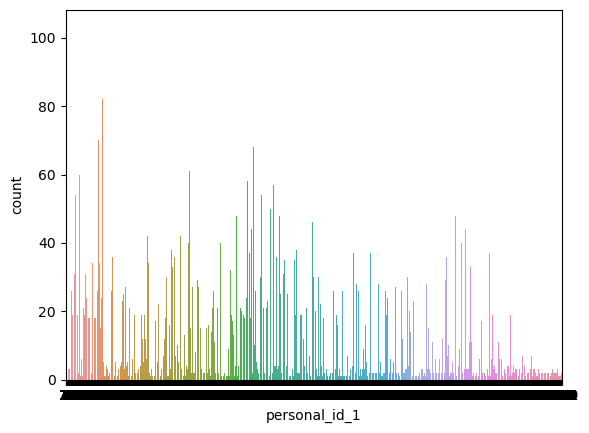

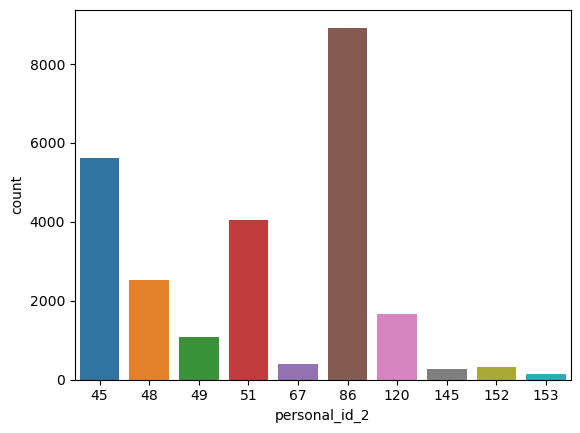

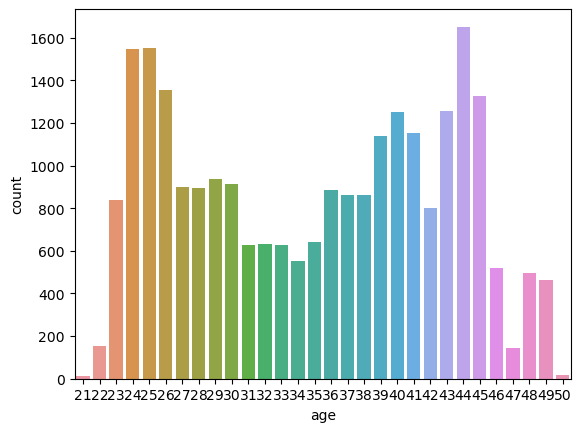

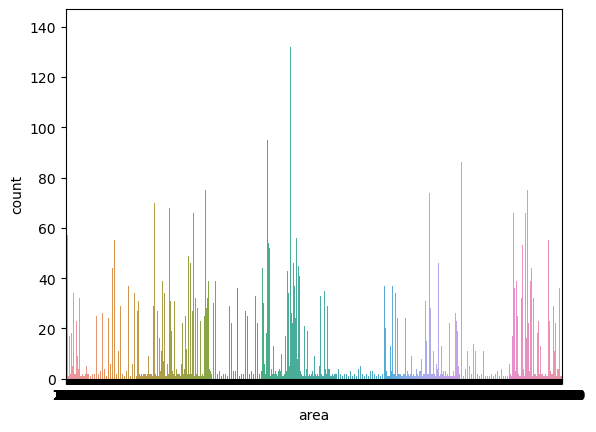

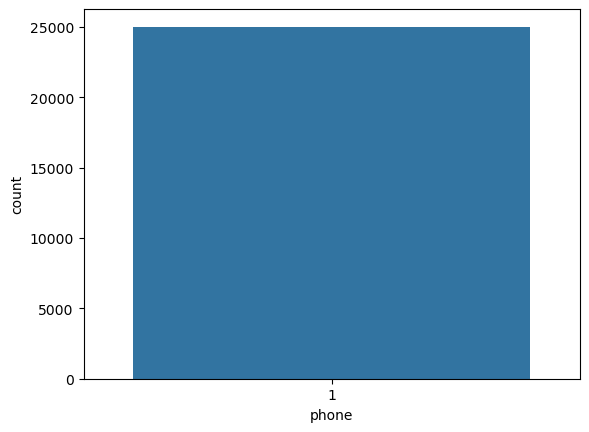

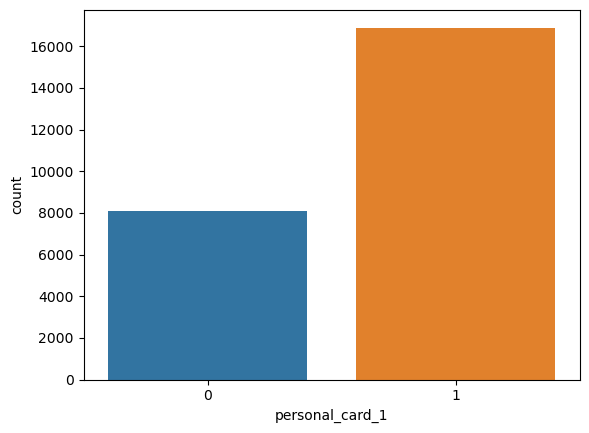

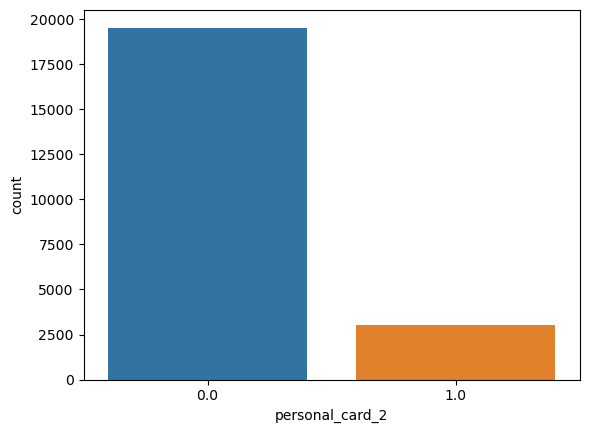

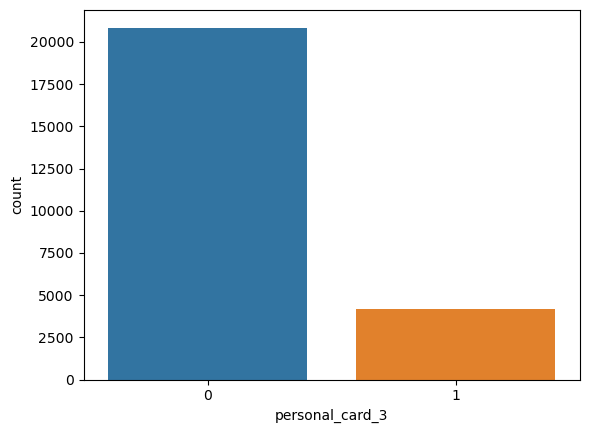

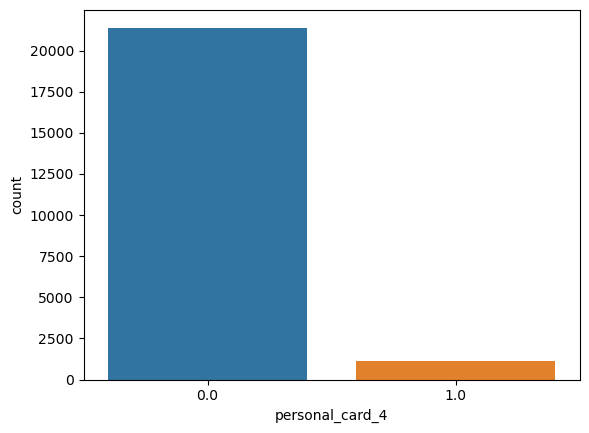

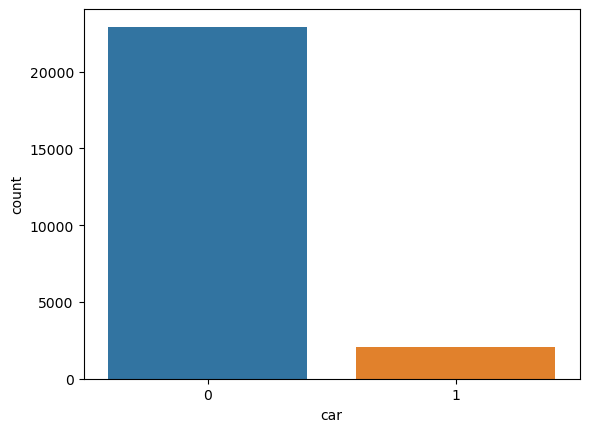

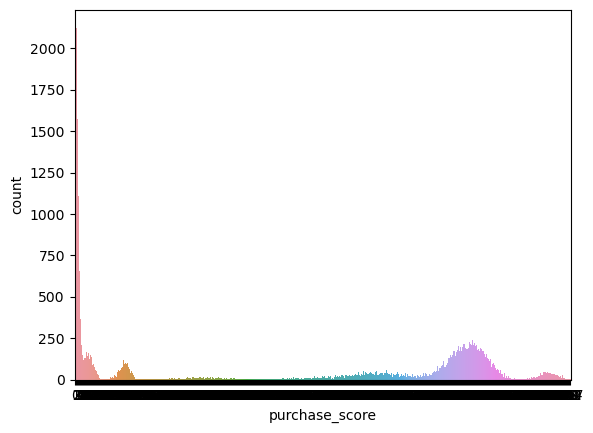

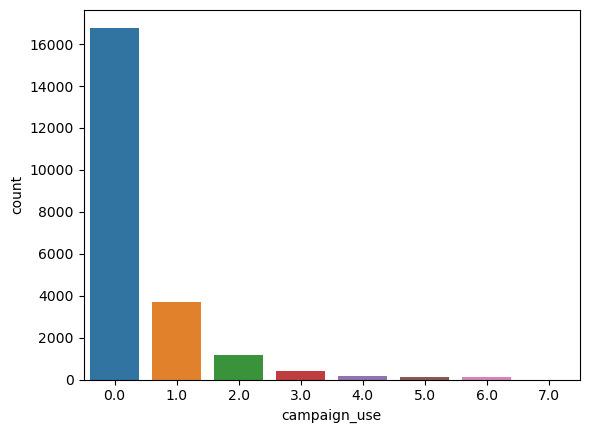

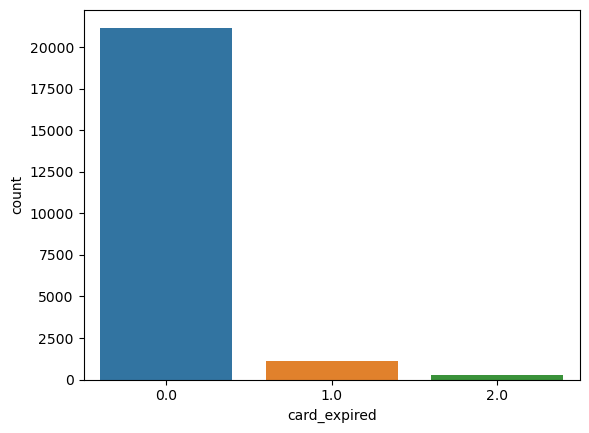

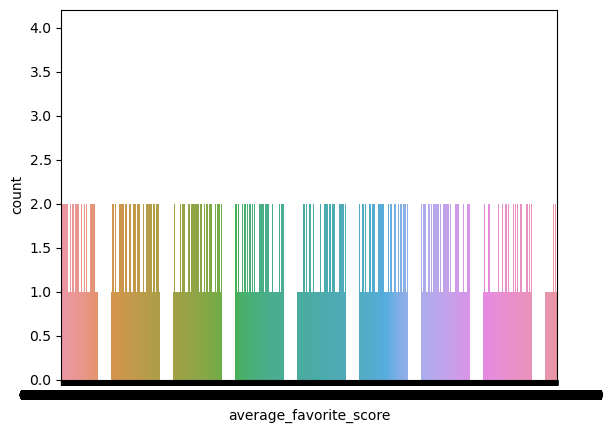

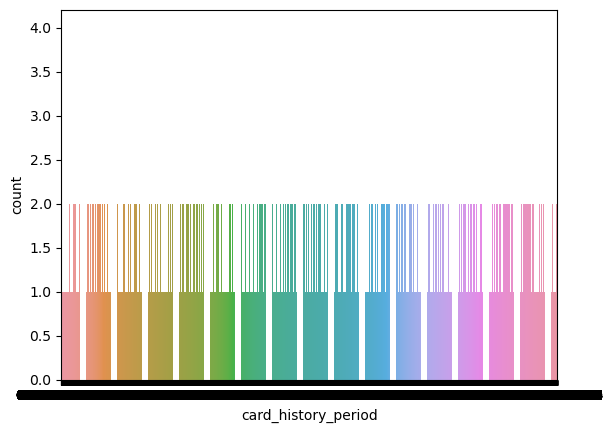

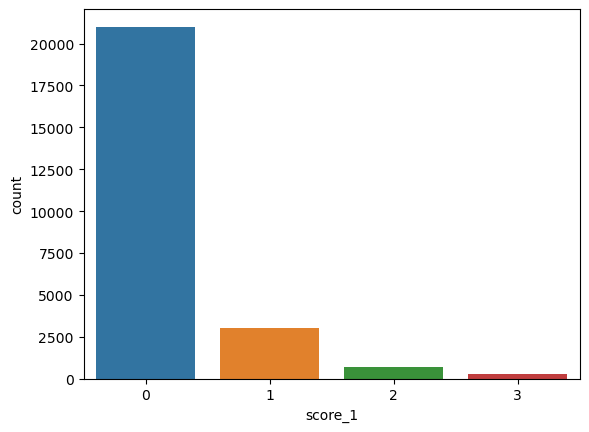

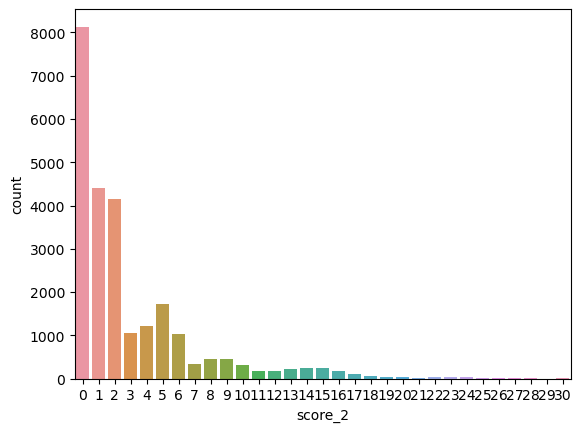

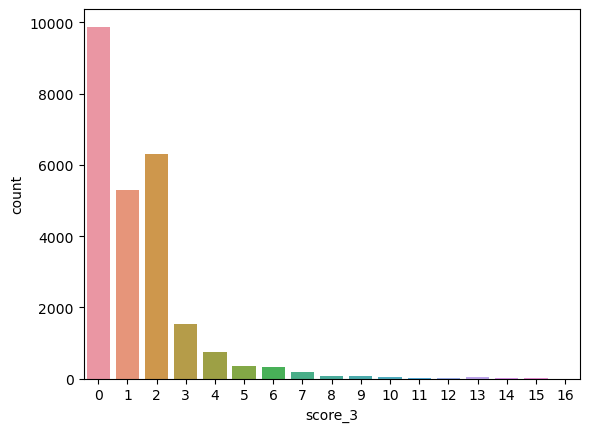

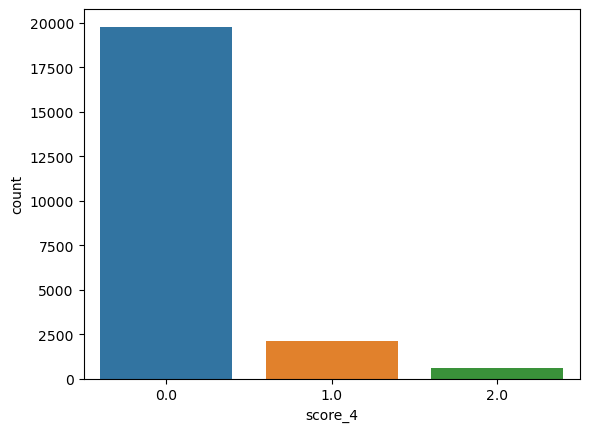

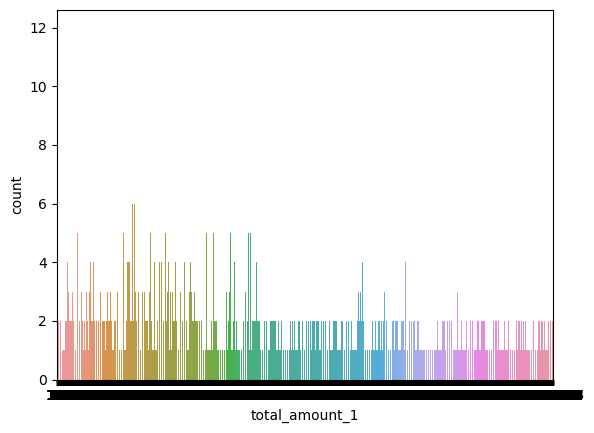

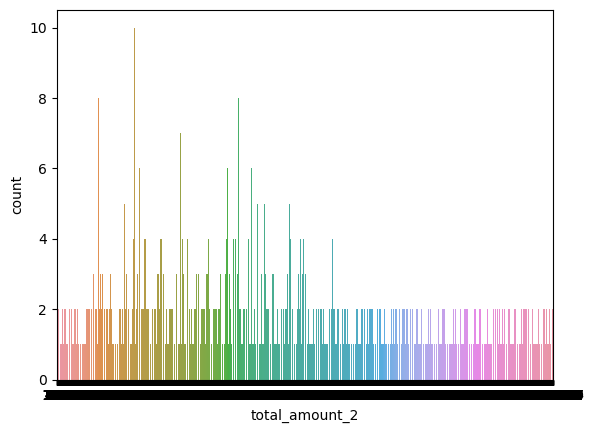

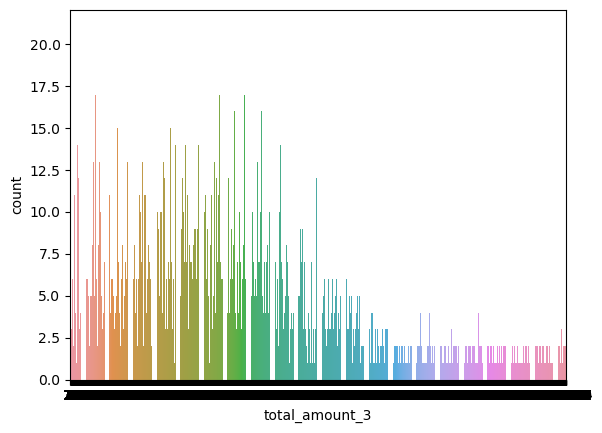

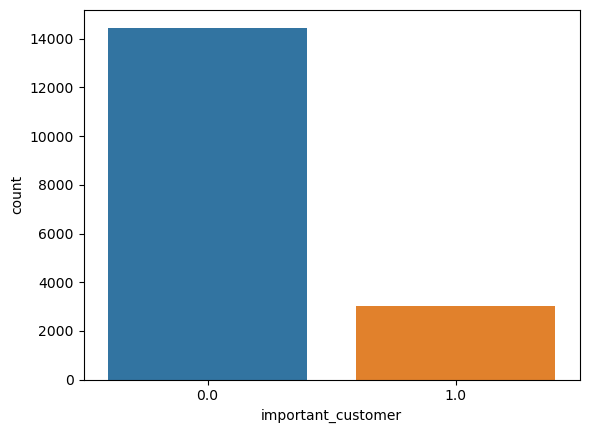

In [30]:
x=1
plt.figure(figsize=(5,5))
for i in num_cols:
    sns.countplot(data=combined,x=i)
    print('\n')
    plt.show()

In [31]:
combined['id'].value_counts()

17500    1
9150     1
9172     1
9171     1
9170     1
        ..
831      1
830      1
829      1
828      1
17499    1
Name: id, Length: 25000, dtype: int64

In [32]:
combined['id'].unique()

array([17500, 17501, 17502, ..., 17497, 17498, 17499])

In [33]:
combined.head()

,id,purchase_amount,asset_amount,average_ratio,personal_id_1,personal_id_2,age,area,job_type,phone,personal_card_1,personal_card_2,personal_card_3,personal_card_4,car,purchase_score,campaign_use,card_expired,average_favorite_score,card_history_period,score_1,score_2,score_3,score_4,total_amount_1,total_amount_2,total_amount_3,important_customer
0,17500,58752.0,94352,84.560755,244,45,35,1323.0,NaN,1,1,0.0,1,0.0,0,709,3.0,1.0,1.607419,4.221710,0,8,0,1.0,43535,143553,388,NaN
1,17501,41109.0,69151,83.127703,830,67,34,863.0,Salaried,1,1,0.0,0,0.0,0,814,0.0,0.0,0.001650,0.525210,0,11,2,NaN,73287,8895,1382,NaN
2,17502,61863.0,59134,61.132690,2549,45,28,1231.0,Salaried,1,0,0.0,1,NaN,0,3,0.0,NaN,0.006573,0.020912,0,1,0,0.0,4457,15008,2205,NaN
3,17503,38018.0,117158,88.415083,1602,120,36,7084.0,Self employed,1,0,0.0,1,NaN,1,16,0.0,0.0,1.247141,1.898690,1,22,0,NaN,634723,41942,95,NaN
4,17504,41180.0,77888,85.455052,2058,45,38,996.0,Self employed,1,1,NaN,0,0.0,0,4,0.0,0.0,0.016552,0.034810,0,2,0,0.0,99731,13895,1871,NaN


In [34]:
# Replacing weird values
combined = combined.applymap(lambda x: x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                            ).replace(['','nan','!@9#%8','#F$D@*&8'],np.NaN)

In [35]:
combined.head()

,id,purchase_amount,asset_amount,average_ratio,personal_id_1,personal_id_2,age,area,job_type,phone,personal_card_1,personal_card_2,personal_card_3,personal_card_4,car,purchase_score,campaign_use,card_expired,average_favorite_score,card_history_period,score_1,score_2,score_3,score_4,total_amount_1,total_amount_2,total_amount_3,important_customer
0,17500,58752.0,94352,84.560755,244,45,35,1323.0,NaN,1,1,0.0,1,0.0,0,709,3.0,1.0,1.607419,4.221710,0,8,0,1.0,43535,143553,388,NaN
1,17501,41109.0,69151,83.127703,830,67,34,863.0,Salaried,1,1,0.0,0,0.0,0,814,0.0,0.0,0.001650,0.525210,0,11,2,NaN,73287,8895,1382,NaN
2,17502,61863.0,59134,61.132690,2549,45,28,1231.0,Salaried,1,0,0.0,1,NaN,0,3,0.0,NaN,0.006573,0.020912,0,1,0,0.0,4457,15008,2205,NaN
3,17503,38018.0,117158,88.415083,1602,120,36,7084.0,Self employed,1,0,0.0,1,NaN,1,16,0.0,0.0,1.247141,1.898690,1,22,0,NaN,634723,41942,95,NaN
4,17504,41180.0,77888,85.455052,2058,45,38,996.0,Self employed,1,1,NaN,0,0.0,0,4,0.0,0.0,0.016552,0.034810,0,2,0,0.0,99731,13895,1871,NaN


In [36]:
# Treating type of id
combined['id'].value_counts().head(9).index[1:]

Int64Index([9150, 9172, 9171, 9170, 9169, 9168, 9167, 9166], dtype='int64')

In [37]:
combined['average_ratioa']=combined['average_ratio'].astype(float)

In [38]:
extreme=combined[(combined['average_ratio']>85)|(combined['average_ratio']<0)].index

In [39]:
for i in extreme:
    combined.loc[i,'average_ratio']=np.nan

In [40]:
combined.head()

,id,purchase_amount,asset_amount,average_ratio,personal_id_1,personal_id_2,age,area,job_type,phone,personal_card_1,personal_card_2,personal_card_3,personal_card_4,car,purchase_score,campaign_use,card_expired,average_favorite_score,card_history_period,score_1,score_2,score_3,score_4,total_amount_1,total_amount_2,total_amount_3,important_customer,average_ratioa
0,17500,58752.0,94352,NaN,244,45,35,1323.0,NaN,1,1,0.0,1,0.0,0,709,3.0,1.0,1.607419,4.221710,0,8,0,1.0,43535,143553,388,NaN,84.560755
1,17501,41109.0,69151,83.127703,830,67,34,863.0,Salaried,1,1,0.0,0,0.0,0,814,0.0,0.0,0.001650,0.525210,0,11,2,NaN,73287,8895,1382,NaN,83.127703
2,17502,61863.0,59134,61.132690,2549,45,28,1231.0,Salaried,1,0,0.0,1,NaN,0,3,0.0,NaN,0.006573,0.020912,0,1,0,0.0,4457,15008,2205,NaN,61.132690
3,17503,38018.0,117158,NaN,1602,120,36,7084.0,Self employed,1,0,0.0,1,NaN,1,16,0.0,0.0,1.247141,1.898690,1,22,0,NaN,634723,41942,95,NaN,88.415083
4,17504,41180.0,77888,NaN,2058,45,38,996.0,Self employed,1,1,NaN,0,0.0,0,4,0.0,0.0,0.016552,0.034810,0,2,0,0.0,99731,13895,1871,NaN,85.455052
